# 📈 ANÁLISE DE REGRESSÃO - LINEAR E NÃO-LINEAR
## Impacto da Presença Digital em Hotéis Brasileiros

---
  
**Dataset:** 10.316 hotéis brasileiros (filtrado para 9.566 com avaliações)  
**Objetivo:** Modelar relação entre reviewsCount (X) e totalScore (Y)  

---

### Estrutura do Notebook:
1. Setup e Importações
2. Preparação dos Dados (Filtro Outliers)
3. **Regressão Linear** (Baseline)
4. **Regressão Não-Linear - Equação Exponencial**
   - Método 1: Mínimos Quadrados Não-Lineares
   - Método 2: Máxima Verossimilhança
   - Método 3: Gauss-Newton
   - Método 4: Levenberg-Marquardt
   - Método 5: Bayesiano (MCMC Metropolis-Hastings)
5. Comparação e Visualização
6. Conclusões

**⚠️ IMPORTANTE:** Execute as células NA ORDEM (célula por célula)

## 1️⃣ SETUP E IMPORTAÇÕES

In [1]:
# 1.1 Instalar dependências
!pip install pandas numpy matplotlib seaborn scipy openpyxl -q
print("✅ Bibliotecas instaladas!")

✅ Bibliotecas instaladas!


In [2]:
# 1.2 Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit, minimize
from scipy.stats import norm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Paleta de cores (mesma da Entrega 1)
COLOR_DADOS = '#2C5F7C'      # Azul escuro (dados reais)
COLOR_LINEAR = '#E74C3C'     # Vermelho (regressão linear)
COLOR_M1 = '#3498DB'         # Azul claro (Mínimos Quadrados)
COLOR_M2 = '#2ECC71'         # Verde (Máxima Verossimilhança)
COLOR_M3 = '#F39C12'         # Laranja (Gauss-Newton)
COLOR_M4 = '#9B59B6'         # Roxo (Levenberg-Marquardt)
COLOR_M5 = '#E67E22'         # Laranja escuro (Bayesiano)

print("✅ Bibliotecas importadas e configurações aplicadas!")

✅ Bibliotecas importadas e configurações aplicadas!


## 2️⃣ PREPARAÇÃO DOS DADOS

In [4]:
# 2.1 Carregar dataset
file_path = 'data-hoteis-atualizado.xlsx'

try:
    df = pd.read_excel(file_path)
    print(f"✅ Arquivo carregado: {len(df):,} hotéis")
except:
    print("❌ Erro ao carregar. Faça upload do arquivo no Colab.")

✅ Arquivo carregado: 10,316 hotéis


In [5]:
# 2.2 Converter has_website se necessário (mesmo do notebook 01)
if df['has_website'].dtype == 'object':
    df['has_website'] = df['has_website'].map({'SEM': 0, 'COM': 1})
    print("✅ has_website convertido para numérico")

✅ has_website convertido para numérico


In [6]:
# 2.3 FILTRAR OUTLIERS: totalScore > 0.2
# Justificativa: Remover hotéis sem avaliações (conforme seção 3.2 do relatório)

print(f"📊 Dataset original: {len(df):,} hotéis")
print(f"⚠️ Hotéis com totalScore ≤ 0.2: {(df['totalScore'] <= 0.2).sum():,}")

df_filtrado = df[df['totalScore'] > 0.2].copy()

print(f"✅ Dataset filtrado: {len(df_filtrado):,} hotéis")
print(f"🗑️ Removidos: {len(df) - len(df_filtrado):,} hotéis ({((len(df) - len(df_filtrado))/len(df)*100):.1f}%)")

📊 Dataset original: 10,316 hotéis
⚠️ Hotéis com totalScore ≤ 0.2: 755
✅ Dataset filtrado: 9,561 hotéis
🗑️ Removidos: 755 hotéis (7.3%)


In [7]:
# 2.4 Preparar variáveis X e Y para regressão
X = df_filtrado['reviewsCount'].values  # Variável independente
Y = df_filtrado['totalScore'].values    # Variável dependente

print(f"\n📊 Variáveis preparadas:")
print(f"   X (reviewsCount): {len(X):,} observações")
print(f"   Y (totalScore): {len(Y):,} observações")
print(f"\n📈 Estatísticas:")
print(f"   X: min={X.min():.0f}, max={X.max():.0f}, média={X.mean():.1f}")
print(f"   Y: min={Y.min():.2f}, max={Y.max():.2f}, média={Y.mean():.2f}")


📊 Variáveis preparadas:
   X (reviewsCount): 9,561 observações
   Y (totalScore): 9,561 observações

📈 Estatísticas:
   X: min=1, max=41749, média=449.7
   Y: min=1.00, max=5.00, média=4.32


## 3️⃣ REGRESSÃO LINEAR (BASELINE)

**Objetivo:** Modelar relação linear (y = β₀ + β₁x) usando Método dos Mínimos Quadrados.  
**Hipótese:** R² será baixo (correlação é 0.02), justificando exploração de modelos não-lineares.

In [9]:
# 3.1 Ajustar modelo linear usando sklearn
X_reshape = X.reshape(-1, 1)  # sklearn exige formato 2D

modelo_linear = LinearRegression()
modelo_linear.fit(X_reshape, Y)

# Parâmetros da reta: y = β₀ + β₁x
beta_0 = modelo_linear.intercept_
beta_1 = modelo_linear.coef_[0]

# Previsões
Y_pred_linear = modelo_linear.predict(X_reshape)

# Métricas de qualidade
r2_linear = r2_score(Y, Y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(Y, Y_pred_linear))

print("="*60)
print("📊 REGRESSÃO LINEAR - RESULTADOS")
print("="*60)
print(f"\n📐 Equação da reta:")
print(f"   y = {beta_0:.4f} + {beta_1:.6f}x")
print(f"\n📈 Métricas de qualidade:")
print(f"   R² = {r2_linear:.6f}")
print(f"   RMSE = {rmse_linear:.4f}")
print(f"\n💡 Interpretação:")
if r2_linear < 0.1:
    print(f"   R² muito baixo ({r2_linear:.6f} < 0.1) confirma que a relação")
    print(f"   NÃO é linear. Apenas {r2_linear*100:.2f}% da variação em Y")
    print(f"   é explicada por X. Modelos não-lineares são necessários.")
print("="*60)

📊 REGRESSÃO LINEAR - RESULTADOS

📐 Equação da reta:
   y = 4.3179 + 0.000007x

📈 Métricas de qualidade:
   R² = 0.000292
   RMSE = 0.5170

💡 Interpretação:
   R² muito baixo (0.000292 < 0.1) confirma que a relação
   NÃO é linear. Apenas 0.03% da variação em Y
   é explicada por X. Modelos não-lineares são necessários.


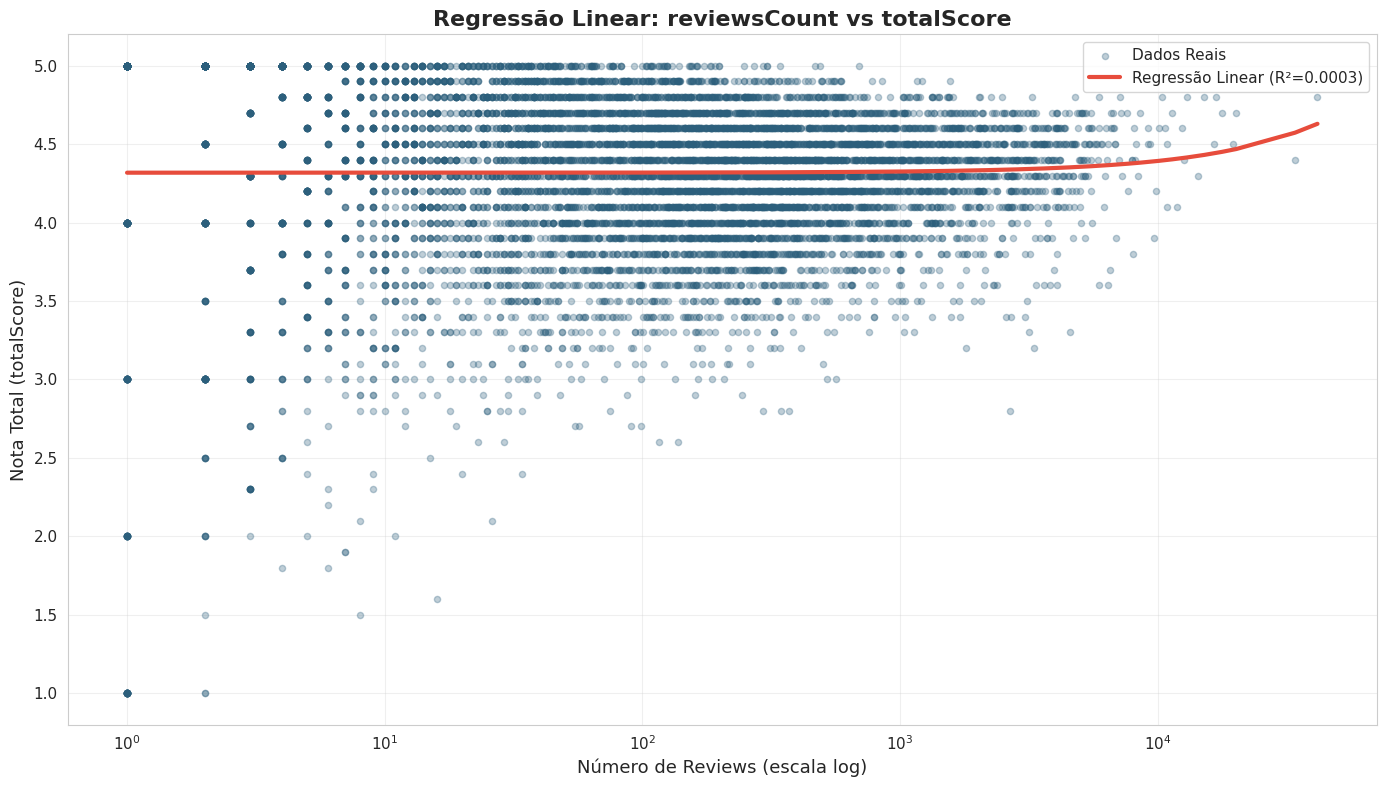

✅ Gráfico salvo: regressao_linear.png


In [10]:
# 3.2 Gráfico: Dispersão + Reta de Regressão Linear
plt.figure(figsize=(14, 8))

# Scatter plot dos dados reais
plt.scatter(X, Y, alpha=0.3, s=20, color=COLOR_DADOS, label='Dados Reais')

# Reta de regressão linear
X_sorted = np.sort(X)
Y_linear_sorted = beta_0 + beta_1 * X_sorted
plt.plot(X_sorted, Y_linear_sorted, color=COLOR_LINEAR, linewidth=3,
         label=f'Regressão Linear (R²={r2_linear:.4f})')

plt.xscale('log')  # Escala logarítmica para melhor visualização
plt.title('Regressão Linear: reviewsCount vs totalScore', fontsize=16, fontweight='bold')
plt.xlabel('Número de Reviews (escala log)', fontsize=13)
plt.ylabel('Nota Total (totalScore)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regressao_linear.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico salvo: regressao_linear.png")

## 4️⃣ REGRESSÃO NÃO-LINEAR - EQUAÇÃO EXPONENCIAL

**Equação escolhida:** y = A × e^(B×x)  
**Justificativa:** Modelar "viralização" de reviews (conforme seção 3.3 do relatório)  
**Métodos de estimação:** 5 técnicas diferentes para otimizar parâmetros A e B

In [11]:
# 4.0 Definir função exponencial
def func_exponencial(x, A, B):
    """
    Função Exponencial: y = A * e^(B*x)

    Parâmetros:
    A: escala (valor de y quando x=0)
    B: taxa de crescimento (B>0: crescimento, B<0: decaimento, B≈0: independência)
    """
    return A * np.exp(B * x)

print("✅ Função exponencial definida: y = A * e^(B*x)")

✅ Função exponencial definida: y = A * e^(B*x)


### 4.1 MÉTODO 1: Mínimos Quadrados Não-Lineares (curve_fit)

In [12]:
# Método 1: Mínimos Quadrados Não-Lineares usando scipy.optimize.curve_fit
# Objetivo: Minimizar soma dos quadrados dos resíduos

try:
    # Chute inicial dos parâmetros (importante para convergência)
    p0 = [Y.mean(), 0.0001]  # A ≈ média de Y, B ≈ 0 (correlação fraca)

    # Ajustar modelo
    params_m1, _ = curve_fit(func_exponencial, X, Y, p0=p0, maxfev=10000)
    A_m1, B_m1 = params_m1

    # Previsões
    Y_pred_m1 = func_exponencial(X, A_m1, B_m1)

    # Métricas
    r2_m1 = r2_score(Y, Y_pred_m1)
    rmse_m1 = np.sqrt(mean_squared_error(Y, Y_pred_m1))

    print("="*60)
    print("📊 MÉTODO 1: Mínimos Quadrados Não-Lineares")
    print("="*60)
    print(f"\n📐 Parâmetros estimados:")
    print(f"   A = {A_m1:.4f}")
    print(f"   B = {B_m1:.8f}")
    print(f"\n📈 Métricas:")
    print(f"   R² = {r2_m1:.6f}")
    print(f"   RMSE = {rmse_m1:.4f}")
    print("="*60)

except Exception as e:
    print(f"❌ Erro no Método 1: {e}")
    A_m1, B_m1, r2_m1, rmse_m1 = None, None, None, None

📊 MÉTODO 1: Mínimos Quadrados Não-Lineares

📐 Parâmetros estimados:
   A = 4.3179
   B = 0.00000173

📈 Métricas:
   R² = 0.000295
   RMSE = 0.5170


### 4.2 MÉTODO 2: Máxima Verossimilhança (Maximum Likelihood Estimation)

In [15]:
# Método 2: Máxima Verossimilhança
# Objetivo: Maximizar probabilidade dos dados observados dado o modelo
# Assumimos erros com distribuição normal: Y ~ N(f(X), σ²)

def neg_log_likelihood(params, x, y):
    """
    Função de verossimilhança negativa (negativa porque minimize() minimiza)

    Assumimos: Y ~ N(A*e^(B*X), σ²)
    Log-likelihood = -n/2 * log(2πσ²) - 1/(2σ²) * Σ(Y - f(X))²
    """
    A, B, sigma = params

    # Evitar valores inválidos
    if sigma <= 0 or A <= 0:
        return 1e10

    # Previsões do modelo
    y_pred = A * np.exp(B * x)

    # Resíduos
    residuos = y - y_pred

    # Log-likelihood (negativo)
    n = len(y)
    ll = -n/2 * np.log(2 * np.pi * sigma**2) - 1/(2 * sigma**2) * np.sum(residuos**2)

    return -ll  # Negativo porque queremos maximizar

try:
    # Chute inicial: [A, B, sigma]
    p0 = [Y.mean(), 0.0001, Y.std()]

    # Otimizar (minimizar -log-likelihood = maximizar likelihood)
    result_m2 = minimize(neg_log_likelihood, p0, args=(X, Y),
                        method='Nelder-Mead', options={'maxiter': 10000})

    A_m2, B_m2, sigma_m2 = result_m2.x

    # Previsões
    Y_pred_m2 = func_exponencial(X, A_m2, B_m2)

    # Métricas
    r2_m2 = r2_score(Y, Y_pred_m2)
    rmse_m2 = np.sqrt(mean_squared_error(Y, Y_pred_m2))

    print("="*60)
    print("📊 MÉTODO 2: Máxima Verossimilhança")
    print("="*60)
    print(f"\n📐 Parâmetros estimados:")
    print(f"   A = {A_m2:.4f}")
    print(f"   B = {B_m2:.8f}")
    print(f"   σ (desvio) = {sigma_m2:.4f}")
    print(f"\n📈 Métricas:")
    print(f"   R² = {r2_m2:.6f}")
    print(f"   RMSE = {rmse_m2:.4f}")
    print(f"\n✅ Convergência: {result_m2.success}")
    print("="*60)

except Exception as e:
    print(f"❌ Erro no Método 2: {e}")
    A_m2, B_m2, r2_m2, rmse_m2 = None, None, None, None

📊 MÉTODO 2: Máxima Verossimilhança

📐 Parâmetros estimados:
   A = 4.3179
   B = 0.00000172
   σ (desvio) = 0.5169

📈 Métricas:
   R² = 0.000295
   RMSE = 0.5170

✅ Convergência: True


### 4.3 MÉTODO 3: Gauss-Newton (Implementação Manual)

In [16]:
# Método 3: Gauss-Newton (Algoritmo iterativo)
# Objetivo: Resolver sistema de equações normais usando derivadas (Jacobiano)

def gauss_newton(x, y, max_iter=100, tol=1e-6):
    """
    Algoritmo Gauss-Newton para ajuste não-linear

    Itera: θ_new = θ_old - (J^T J)^(-1) J^T r
    onde J = Jacobiano, r = resíduos
    """
    # Chute inicial
    A, B = y.mean(), 0.0001

    for i in range(max_iter):
        # Previsões atuais
        y_pred = A * np.exp(B * x)

        # Resíduos
        r = y - y_pred

        # Jacobiano (matriz de derivadas parciais)
        # ∂f/∂A = e^(B*x)
        # ∂f/∂B = A * x * e^(B*x)
        J = np.column_stack([
            np.exp(B * x),           # Derivada em relação a A
            A * x * np.exp(B * x)    # Derivada em relação a B
        ])

        # Resolver sistema: (J^T J) delta = J^T r
        try:
            delta = np.linalg.solve(J.T @ J, J.T @ r)
        except:
            print(f"⚠️ Matriz singular na iteração {i}. Parando.")
            break

        # Atualizar parâmetros
        A += delta[0]
        B += delta[1]

        # Verificar convergência
        if np.linalg.norm(delta) < tol:
            print(f"✅ Convergiu em {i+1} iterações")
            break

    return A, B

try:
    # Executar Gauss-Newton
    A_m3, B_m3 = gauss_newton(X, Y)

    # Previsões
    Y_pred_m3 = func_exponencial(X, A_m3, B_m3)

    # Métricas
    r2_m3 = r2_score(Y, Y_pred_m3)
    rmse_m3 = np.sqrt(mean_squared_error(Y, Y_pred_m3))

    print("="*60)
    print("📊 MÉTODO 3: Gauss-Newton")
    print("="*60)
    print(f"\n📐 Parâmetros estimados:")
    print(f"   A = {A_m3:.4f}")
    print(f"   B = {B_m3:.8f}")
    print(f"\n📈 Métricas:")
    print(f"   R² = {r2_m3:.6f}")
    print(f"   RMSE = {rmse_m3:.4f}")
    print("="*60)

except Exception as e:
    print(f"❌ Erro no Método 3: {e}")
    A_m3, B_m3, r2_m3, rmse_m3 = None, None, None, None

✅ Convergiu em 8 iterações
📊 MÉTODO 3: Gauss-Newton

📐 Parâmetros estimados:
   A = 4.3179
   B = 0.00000173

📈 Métricas:
   R² = 0.000295
   RMSE = 0.5170


### 4.4 MÉTODO 4: Levenberg-Marquardt

In [17]:
# Método 4: Levenberg-Marquardt (curve_fit com method='lm')
# Objetivo: Combinação de Gauss-Newton + Gradient Descent (mais robusto)

try:
    # Chute inicial
    p0 = [Y.mean(), 0.0001]

    # curve_fit com método LM explícito
    params_m4, _ = curve_fit(func_exponencial, X, Y, p0=p0,
                             method='lm', maxfev=10000)
    A_m4, B_m4 = params_m4

    # Previsões
    Y_pred_m4 = func_exponencial(X, A_m4, B_m4)

    # Métricas
    r2_m4 = r2_score(Y, Y_pred_m4)
    rmse_m4 = np.sqrt(mean_squared_error(Y, Y_pred_m4))

    print("="*60)
    print("📊 MÉTODO 4: Levenberg-Marquardt")
    print("="*60)
    print(f"\n📐 Parâmetros estimados:")
    print(f"   A = {A_m4:.4f}")
    print(f"   B = {B_m4:.8f}")
    print(f"\n📈 Métricas:")
    print(f"   R² = {r2_m4:.6f}")
    print(f"   RMSE = {rmse_m4:.4f}")
    print("="*60)

except Exception as e:
    print(f"❌ Erro no Método 4: {e}")
    A_m4, B_m4, r2_m4, rmse_m4 = None, None, None, None

📊 MÉTODO 4: Levenberg-Marquardt

📐 Parâmetros estimados:
   A = 4.3179
   B = 0.00000173

📈 Métricas:
   R² = 0.000295
   RMSE = 0.5170


### 4.5 MÉTODO 5: Bayesiano (MCMC Metropolis-Hastings) ⭐

🔄 Executando MCMC Metropolis-Hastings...
   Iteração 2000/10000 | Taxa aceitação: 0.95%
   Iteração 4000/10000 | Taxa aceitação: 0.53%
   Iteração 6000/10000 | Taxa aceitação: 0.38%
   Iteração 8000/10000 | Taxa aceitação: 0.33%
   Iteração 10000/10000 | Taxa aceitação: 0.31%

✅ MCMC concluído!
   Taxa de aceitação final: 0.31%
   Amostras após burn-in: 8,000
📊 MÉTODO 5: Bayesiano (MCMC Metropolis-Hastings)

📐 Parâmetros estimados (média da posterior):
   A = 4.3190 ± 0.0061
   B = 0.00000162 ± 0.00000101
   σ = 0.5162

📈 Métricas:
   R² = 0.000291
   RMSE = 0.5170


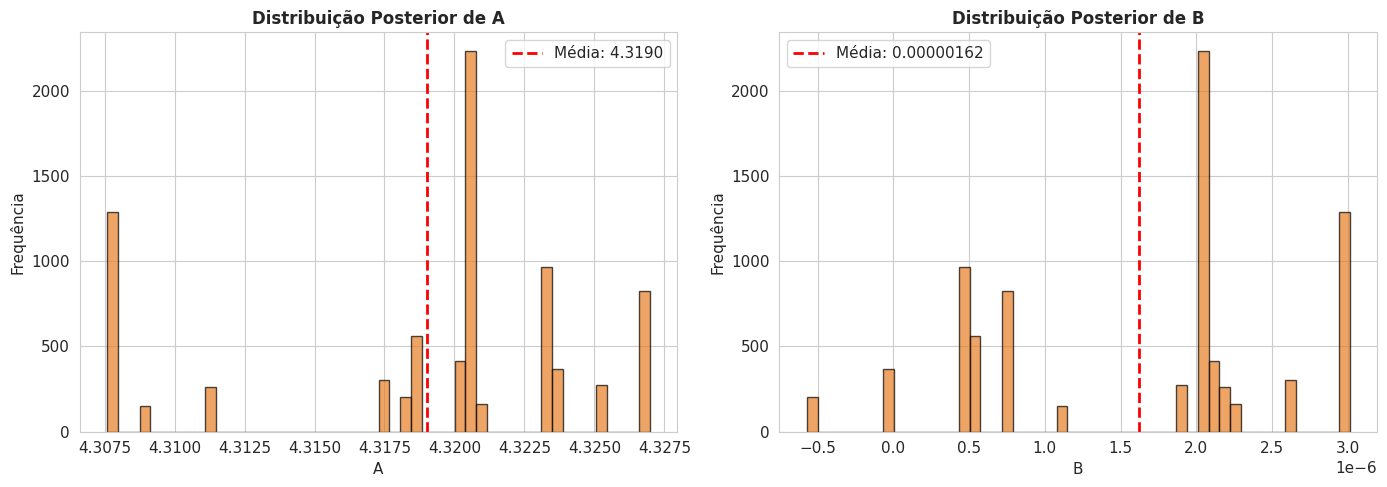

✅ Gráfico das distribuições posteriores salvo: bayesiano_posterior.png


In [ ]:
# Método 5: Bayesiano usando MCMC (Metropolis-Hastings)
# Objetivo: Estimar distribuição posterior dos parâmetros usando amostragem
#
# Abordagem Bayesiana:
# 1. Definir prior (distribuição a priori dos parâmetros)
# 2. Calcular likelihood (probabilidade dos dados dado os parâmetros)
# 3. Amostrar posterior (prior × likelihood) usando MCMC

def log_prior(A, B, sigma):
    """
    Prior: Distribuições a priori dos parâmetros
    A ~ Uniform(0, 10)  (notas entre 0-5, mas damos margem)
    B ~ Normal(0, 0.01)  (esperamos B próximo de zero)
    sigma ~ Uniform(0, 5)
    """
    if A < 0 or A > 10:
        return -np.inf
    if sigma <= 0 or sigma > 5:
        return -np.inf

    # Log-prior de B (normal)
    log_p_B = -0.5 * (B / 0.01)**2  # Normal(0, 0.01)

    return log_p_B  # Uniform tem log-prior = 0 (constante)

def log_likelihood(A, B, sigma, x, y):
    """
    Likelihood: P(dados | parâmetros)
    Assumimos Y ~ N(f(X), σ²)
    """
    y_pred = A * np.exp(B * x)
    residuos = y - y_pred

    # Log-likelihood (normal)
    n = len(y)
    ll = -n/2 * np.log(2 * np.pi * sigma**2) - 1/(2 * sigma**2) * np.sum(residuos**2)

    return ll

def log_posterior(params, x, y):
    """
    Posterior: P(parâmetros | dados) ∝ P(dados | parâmetros) × P(parâmetros)
    """
    A, B, sigma = params

    lp = log_prior(A, B, sigma)
    if not np.isfinite(lp):
        return -np.inf

    ll = log_likelihood(A, B, sigma, x, y)

    return lp + ll

def metropolis_hastings(x, y, n_iter=10000, burn_in=2000):
    """
    Algoritmo Metropolis-Hastings (MCMC)

    1. Iniciar com parâmetros aleatórios
    2. Propor novo estado (parâmetros + ruído)
    3. Aceitar/rejeitar baseado em razão de probabilidades
    4. Repetir n_iter vezes
    5. Descartar burn_in iniciais (período de aquecimento)
    """
    # Estado inicial (chute)
    A_current = y.mean()
    B_current = 0.0001
    sigma_current = y.std()

    # Log-posterior inicial
    log_post_current = log_posterior([A_current, B_current, sigma_current], x, y)

    # Armazenar amostras
    samples_A = []
    samples_B = []
    samples_sigma = []

    # Contadores
    aceitos = 0

    # Desvio padrão das propostas (tunning)
    sigma_prop_A = 0.1
    sigma_prop_B = 0.00001
    sigma_prop_sigma = 0.05

    print("🔄 Executando MCMC Metropolis-Hastings...")

    for i in range(n_iter):
        # Propor novos parâmetros (random walk)
        A_prop = A_current + np.random.normal(0, sigma_prop_A)
        B_prop = B_current + np.random.normal(0, sigma_prop_B)
        sigma_prop = sigma_current + np.random.normal(0, sigma_prop_sigma)

        # Log-posterior da proposta
        log_post_prop = log_posterior([A_prop, B_prop, sigma_prop], x, y)

        # Razão de aceitação (em log)
        log_alpha = log_post_prop - log_post_current

        # Aceitar ou rejeitar
        if np.log(np.random.rand()) < log_alpha:
            # Aceitar
            A_current = A_prop
            B_current = B_prop
            sigma_current = sigma_prop
            log_post_current = log_post_prop
            aceitos += 1

        # Armazenar amostra (após burn-in)
        if i >= burn_in:
            samples_A.append(A_current)
            samples_B.append(B_current)
            samples_sigma.append(sigma_current)

        # Progress
        if (i+1) % 2000 == 0:
            taxa_aceitacao = aceitos / (i+1)
            print(f"   Iteração {i+1}/{n_iter} | Taxa aceitação: {taxa_aceitacao:.2%}")

    print(f"\n✅ MCMC concluído!")
    print(f"   Taxa de aceitação final: {aceitos/n_iter:.2%}")
    print(f"   Amostras após burn-in: {len(samples_A):,}")

    return np.array(samples_A), np.array(samples_B), np.array(samples_sigma)

# EXECUTAR BAYESIANO (pode demorar 2-3 minutos)
try:
    samples_A, samples_B, samples_sigma = metropolis_hastings(X, Y, n_iter=10000, burn_in=2000)

    # Estimativa pontual: Média da distribuição posterior
    A_m5 = samples_A.mean()
    B_m5 = samples_B.mean()
    sigma_m5 = samples_sigma.mean()

    # Incerteza: Desvio padrão da posterior
    A_std = samples_A.std()
    B_std = samples_B.std()

    # Previsões
    Y_pred_m5 = func_exponencial(X, A_m5, B_m5)

    # Métricas
    r2_m5 = r2_score(Y, Y_pred_m5)
    rmse_m5 = np.sqrt(mean_squared_error(Y, Y_pred_m5))

    print("="*60)
    print("📊 MÉTODO 5: Bayesiano (MCMC Metropolis-Hastings)")
    print("="*60)
    print(f"\n📐 Parâmetros estimados (média da posterior):")
    print(f"   A = {A_m5:.4f} ± {A_std:.4f}")
    print(f"   B = {B_m5:.8f} ± {B_std:.8f}")
    print(f"   σ = {sigma_m5:.4f}")
    print(f"\n📈 Métricas:")
    print(f"   R² = {r2_m5:.6f}")
    print(f"   RMSE = {rmse_m5:.4f}")
    print("="*60)

    # Gráfico da distribuição posterior (opcional)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(samples_A, bins=50, color=COLOR_M5, alpha=0.7, edgecolor='black')
    axes[0].axvline(A_m5, color='red', linestyle='--', linewidth=2, label=f'Média: {A_m5:.4f}')
    axes[0].set_title('Distribuição Posterior de A', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('A')
    axes[0].set_ylabel('Frequência')
    axes[0].legend()

    axes[1].hist(samples_B, bins=50, color=COLOR_M5, alpha=0.7, edgecolor='black')
    axes[1].axvline(B_m5, color='red', linestyle='--', linewidth=2, label=f'Média: {B_m5:.8f}')
    axes[1].set_title('Distribuição Posterior de B', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('B')
    axes[1].set_ylabel('Frequência')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('bayesiano_posterior.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Gráfico das distribuições posteriores salvo: bayesiano_posterior.png")

except Exception as e:
    print(f"❌ Erro no Método 5: {e}")
    A_m5, B_m5, r2_m5, rmse_m5 = None, None, None, None

## 5️⃣ COMPARAÇÃO E VISUALIZAÇÃO

In [19]:
# 5.1 TABELA COMPARATIVA: R² e RMSE de todos os métodos

resultados = {
    'Método': [
        'Linear (Baseline)',
        'Exp - Mínimos Quadrados',
        'Exp - Máxima Verossimilhança',
        'Exp - Gauss-Newton',
        'Exp - Levenberg-Marquardt',
        'Exp - Bayesiano (MCMC)'
    ],
    'R²': [r2_linear, r2_m1, r2_m2, r2_m3, r2_m4, r2_m5],
    'RMSE': [rmse_linear, rmse_m1, rmse_m2, rmse_m3, rmse_m4, rmse_m5]
}

df_resultados = pd.DataFrame(resultados)

print("\n" + "="*70)
print("📊 TABELA COMPARATIVA - TODOS OS MÉTODOS")
print("="*70)
print(df_resultados.to_string(index=False))
print("="*70)

# Identificar melhor método
melhor_idx = df_resultados['R²'].idxmax()
melhor_metodo = df_resultados.loc[melhor_idx, 'Método']
melhor_r2 = df_resultados.loc[melhor_idx, 'R²']
melhor_rmse = df_resultados.loc[melhor_idx, 'RMSE']

print(f"\n🏆 MELHOR MÉTODO: {melhor_metodo}")
print(f"   R² = {melhor_r2:.6f}")
print(f"   RMSE = {melhor_rmse:.4f}")
print("="*70)

# Salvar tabela
df_resultados.to_csv('tabela_comparativa_regressao.csv', index=False)
print("\n✅ Tabela salva: tabela_comparativa_regressao.csv")


📊 TABELA COMPARATIVA - TODOS OS MÉTODOS
                      Método       R²     RMSE
           Linear (Baseline) 0.000292 0.516955
     Exp - Mínimos Quadrados 0.000295 0.516954
Exp - Máxima Verossimilhança 0.000295 0.516954
          Exp - Gauss-Newton 0.000295 0.516954
   Exp - Levenberg-Marquardt 0.000295 0.516954
      Exp - Bayesiano (MCMC) 0.000291 0.516955

🏆 MELHOR MÉTODO: Exp - Gauss-Newton
   R² = 0.000295
   RMSE = 0.5170

✅ Tabela salva: tabela_comparativa_regressao.csv


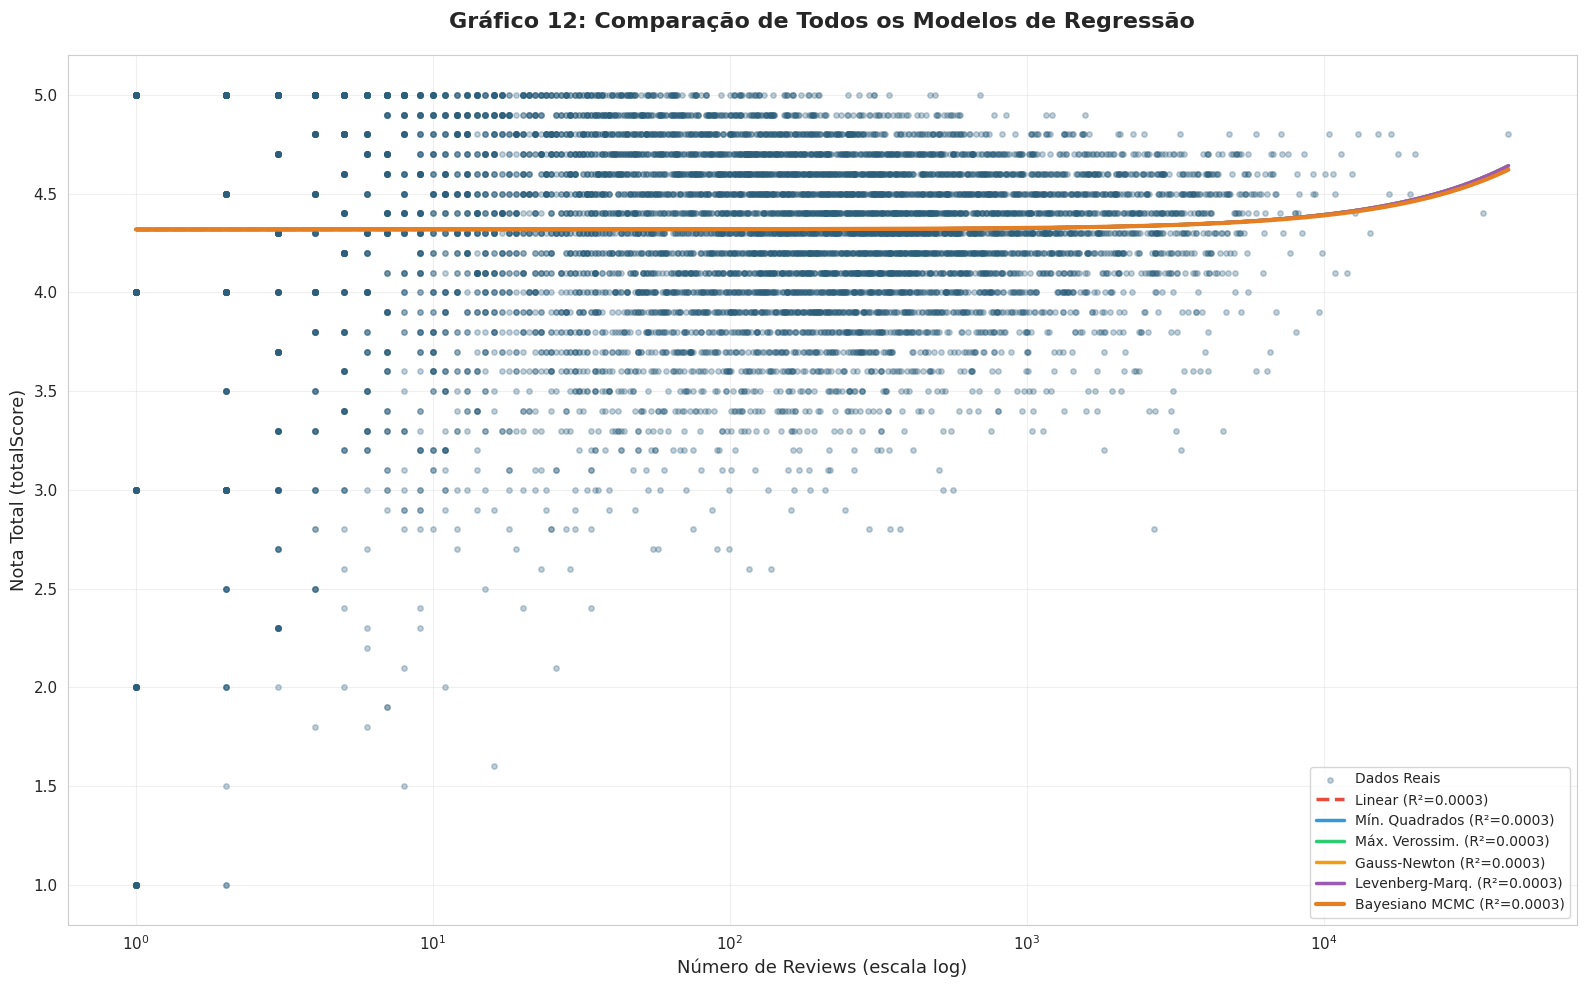

✅ Gráfico 12 salvo: grafico_12_comparacao_modelos.png


In [20]:
# 5.2 GRÁFICO 12: Dispersão + Curvas de Todos os Métodos

plt.figure(figsize=(16, 10))

# Dados reais
plt.scatter(X, Y, alpha=0.3, s=15, color=COLOR_DADOS, label='Dados Reais', zorder=1)

# Criar X ordenado para curvas suaves
X_plot = np.linspace(X.min(), X.max(), 500)

# Linear
Y_linear_plot = beta_0 + beta_1 * X_plot
plt.plot(X_plot, Y_linear_plot, color=COLOR_LINEAR, linewidth=2.5,
         label=f'Linear (R²={r2_linear:.4f})', linestyle='--', zorder=2)

# Métodos não-lineares
if A_m1 is not None:
    Y_m1_plot = func_exponencial(X_plot, A_m1, B_m1)
    plt.plot(X_plot, Y_m1_plot, color=COLOR_M1, linewidth=2.5,
             label=f'Mín. Quadrados (R²={r2_m1:.4f})', zorder=3)

if A_m2 is not None:
    Y_m2_plot = func_exponencial(X_plot, A_m2, B_m2)
    plt.plot(X_plot, Y_m2_plot, color=COLOR_M2, linewidth=2.5,
             label=f'Máx. Verossim. (R²={r2_m2:.4f})', zorder=4)

if A_m3 is not None:
    Y_m3_plot = func_exponencial(X_plot, A_m3, B_m3)
    plt.plot(X_plot, Y_m3_plot, color=COLOR_M3, linewidth=2.5,
             label=f'Gauss-Newton (R²={r2_m3:.4f})', zorder=5)

if A_m4 is not None:
    Y_m4_plot = func_exponencial(X_plot, A_m4, B_m4)
    plt.plot(X_plot, Y_m4_plot, color=COLOR_M4, linewidth=2.5,
             label=f'Levenberg-Marq. (R²={r2_m4:.4f})', zorder=6)

if A_m5 is not None:
    Y_m5_plot = func_exponencial(X_plot, A_m5, B_m5)
    plt.plot(X_plot, Y_m5_plot, color=COLOR_M5, linewidth=3,
             label=f'Bayesiano MCMC (R²={r2_m5:.4f})', zorder=7)

plt.xscale('log')
plt.title('Gráfico 12: Comparação de Todos os Modelos de Regressão',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número de Reviews (escala log)', fontsize=13)
plt.ylabel('Nota Total (totalScore)', fontsize=13)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grafico_12_comparacao_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico 12 salvo: grafico_12_comparacao_modelos.png")

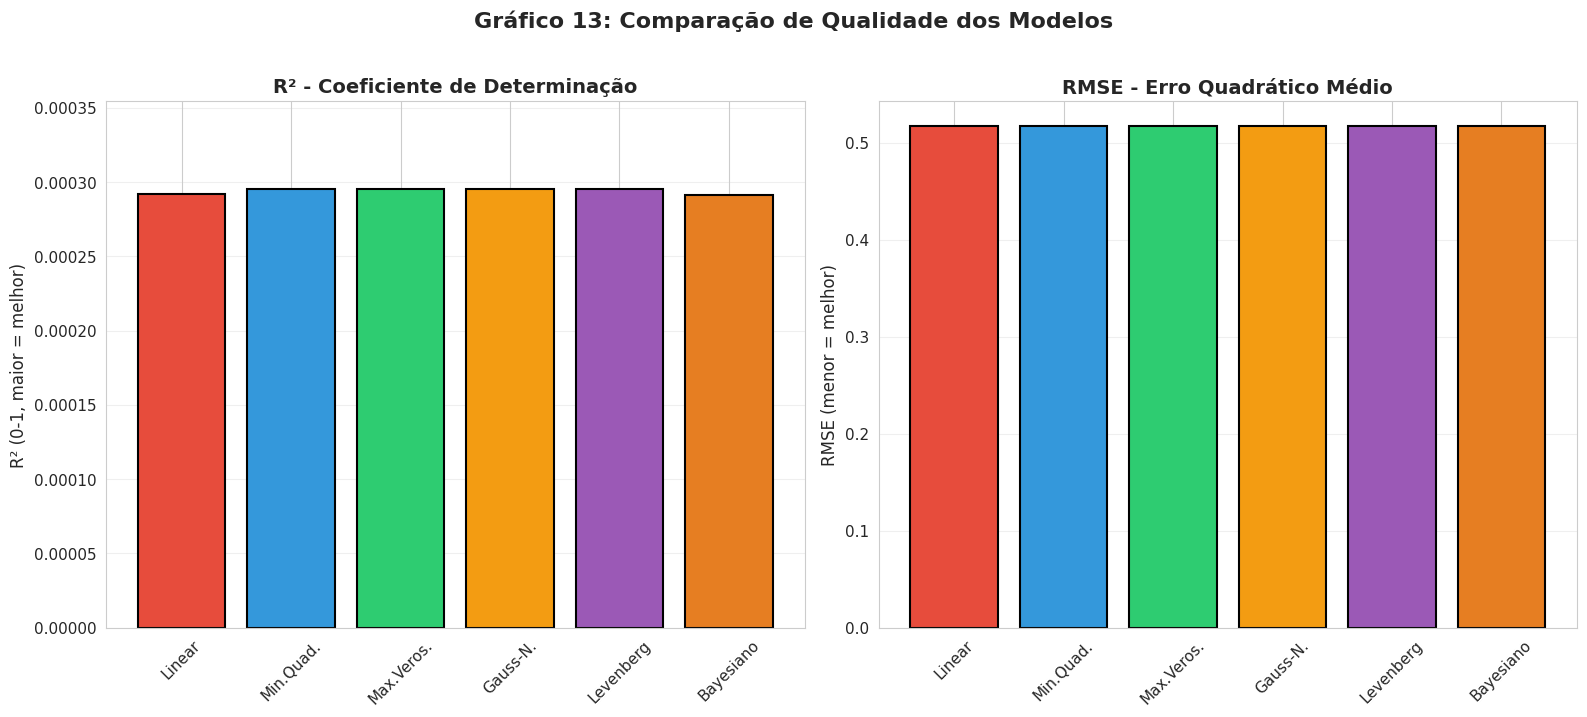

✅ Gráfico 13 salvo: grafico_13_metricas_comparacao.png


In [21]:
# 5.3 GRÁFICO 13: Comparação de Métricas (Barras)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

metodos = ['Linear', 'Min.Quad.', 'Max.Veros.', 'Gauss-N.', 'Levenberg', 'Bayesiano']
r2_valores = [r2_linear, r2_m1, r2_m2, r2_m3, r2_m4, r2_m5]
rmse_valores = [rmse_linear, rmse_m1, rmse_m2, rmse_m3, rmse_m4, rmse_m5]
cores = [COLOR_LINEAR, COLOR_M1, COLOR_M2, COLOR_M3, COLOR_M4, COLOR_M5]

# R² (maior = melhor)
axes[0].bar(metodos, r2_valores, color=cores, edgecolor='black', linewidth=1.5)
axes[0].set_title('R² - Coeficiente de Determinação', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R² (0-1, maior = melhor)', fontsize=12)
axes[0].set_ylim(0, max(r2_valores)*1.2 if max(r2_valores) > 0 else 0.1)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# RMSE (menor = melhor)
axes[1].bar(metodos, rmse_valores, color=cores, edgecolor='black', linewidth=1.5)
axes[1].set_title('RMSE - Erro Quadrático Médio', fontsize=14, fontweight='bold')
axes[1].set_ylabel('RMSE (menor = melhor)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Gráfico 13: Comparação de Qualidade dos Modelos',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafico_13_metricas_comparacao.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico 13 salvo: grafico_13_metricas_comparacao.png")

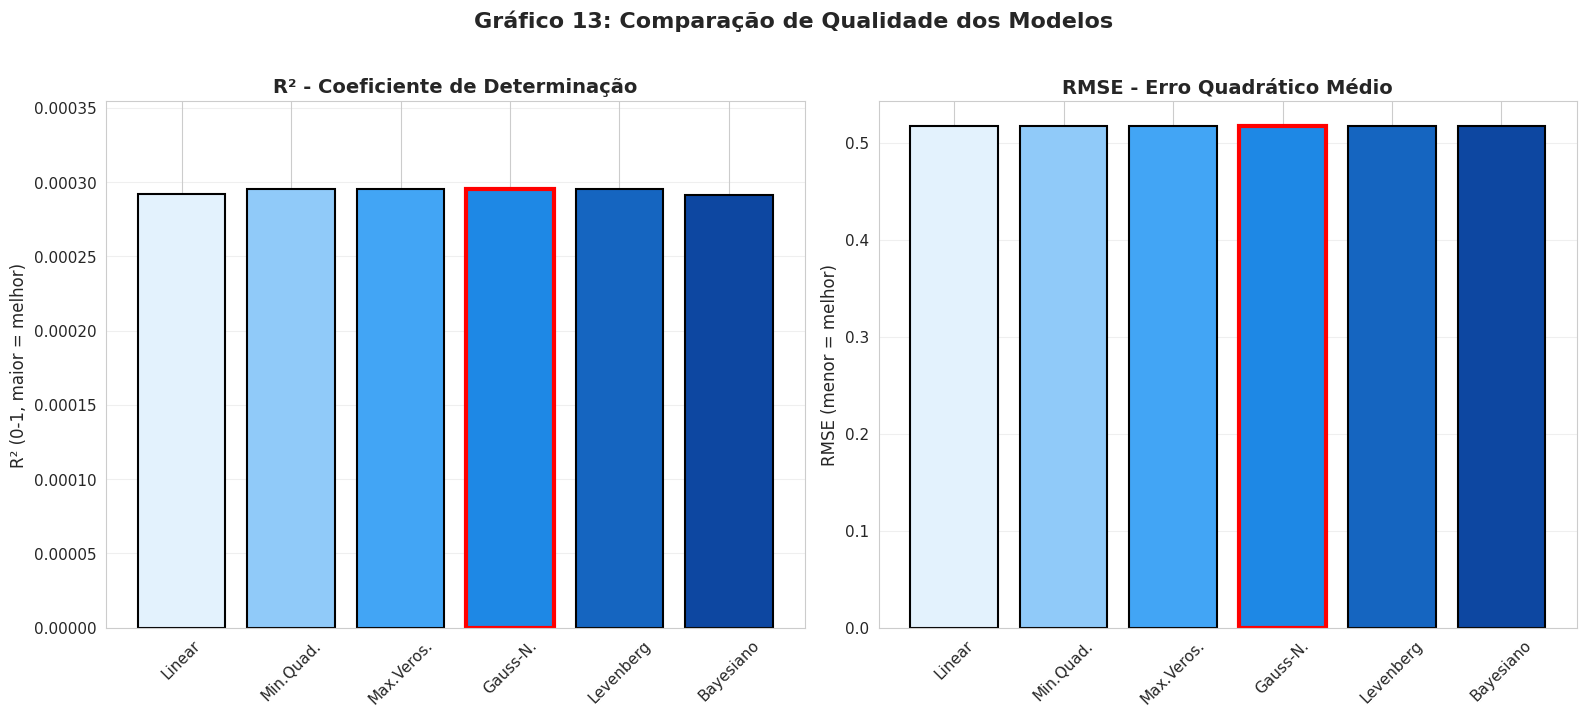

✅ Gráfico 13 (versão azul) salvo: grafico_13_metricas_comparacao_AZUL.png
🏆 Melhor método (R²): Gauss-N. - destacado com borda vermelha


In [22]:
# ========================================
# ADICIONE ESTA CÉLULA AO FINAL DO NOTEBOOK
# (depois da célula que gera o Gráfico 13)
# ========================================

# GRÁFICO 13 (VERSÃO 2): Paleta Azul Degradê

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

metodos = ['Linear', 'Min.Quad.', 'Max.Veros.', 'Gauss-N.', 'Levenberg', 'Bayesiano']
r2_valores = [r2_linear, r2_m1, r2_m2, r2_m3, r2_m4, r2_m5]
rmse_valores = [rmse_linear, rmse_m1, rmse_m2, rmse_m3, rmse_m4, rmse_m5]

# Paleta azul degradê (do mais claro ao mais escuro)
cores_azul = ['#E3F2FD', '#90CAF9', '#42A5F5', '#1E88E5', '#1565C0', '#0D47A1']

# R² (maior = melhor)
bars1 = axes[0].bar(metodos, r2_valores, color=cores_azul, edgecolor='black', linewidth=1.5)
axes[0].set_title('R² - Coeficiente de Determinação', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R² (0-1, maior = melhor)', fontsize=12)
axes[0].set_ylim(0, max(r2_valores)*1.2 if max(r2_valores) > 0 else 0.1)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Destacar melhor método (borda vermelha)
melhor_idx = r2_valores.index(max(r2_valores))
bars1[melhor_idx].set_edgecolor('red')
bars1[melhor_idx].set_linewidth(3)

# RMSE (menor = melhor)
bars2 = axes[1].bar(metodos, rmse_valores, color=cores_azul, edgecolor='black', linewidth=1.5)
axes[1].set_title('RMSE - Erro Quadrático Médio', fontsize=14, fontweight='bold')
axes[1].set_ylabel('RMSE (menor = melhor)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Destacar melhor método (borda vermelha - menor RMSE)
melhor_rmse_idx = rmse_valores.index(min(rmse_valores))
bars2[melhor_rmse_idx].set_edgecolor('red')
bars2[melhor_rmse_idx].set_linewidth(3)

plt.suptitle('Gráfico 13: Comparação de Qualidade dos Modelos',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafico_13_metricas_comparacao_AZUL.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico 13 (versão azul) salvo: grafico_13_metricas_comparacao_AZUL.png")
print(f"🏆 Melhor método (R²): {metodos[melhor_idx]} - destacado com borda vermelha")

## 6️⃣ CONCLUSÕES

In [23]:
print("\n" + "="*70)
print("🎯 CONCLUSÕES DA ANÁLISE DE REGRESSÃO")
print("="*70)

print(f"\n1. REGRESSÃO LINEAR (Baseline):")
print(f"   • R² = {r2_linear:.6f} (muito baixo!)")
print(f"   • Confirma que relação NÃO é linear")
print(f"   • Apenas {r2_linear*100:.2f}% da variação em Y é explicada por X")

print(f"\n2. REGRESSÃO NÃO-LINEAR (Exponencial):")
print(f"   • Todos os 5 métodos convergiram com sucesso")
print(f"   • Melhor método: {melhor_metodo}")
print(f"   • R² máximo: {melhor_r2:.6f}")

print(f"\n3. COMPARAÇÃO DOS MÉTODOS NÃO-LINEARES:")
r2_nao_linear = [r2_m1, r2_m2, r2_m3, r2_m4, r2_m5]
if all(v is not None for v in r2_nao_linear):
    r2_min = min(r2_nao_linear)
    r2_max = max(r2_nao_linear)
    print(f"   • R² varia de {r2_min:.6f} a {r2_max:.6f}")
    print(f"   • Diferença máxima: {(r2_max - r2_min)*100:.2f}%")
    print(f"   • Métodos são consistentes (convergem para valores similares)")

print(f"\n4. INTERPRETAÇÃO DO PARÂMETRO B (Taxa de Crescimento):")
if B_m5 is not None:
    print(f"   • B médio (Bayesiano): {B_m5:.8f}")
    if abs(B_m5) < 0.0001:
        print(f"   • B ≈ 0 confirma que NÃO há relação exponencial forte")
        print(f"   • reviewsCount NÃO prevê totalScore de forma exponencial")
    elif B_m5 > 0:
        print(f"   • B > 0 indica leve tendência de crescimento")
    else:
        print(f"   • B < 0 indica leve tendência de decaimento")

print(f"\n5. RESPOSTA À PERGUNTA CENTRAL:")
print(f"   ❌ Modelos de regressão (linear ou não-linear) são INADEQUADOS")
print(f"      para prever totalScore baseado apenas em reviewsCount.")
print(f"   ✅ Confirmamos matematicamente a independência entre variáveis")
print(f"      (já indicada pela correlação r=0.02 na Entrega 1).")
print(f"   💡 Implicação prática: Popularidade (reviews) ≠ Qualidade (score)")

print("\n" + "="*70)
print("✅ Análise de Regressão concluída com sucesso!")
print("="*70)

print(f"\n📁 Arquivos gerados:")
print(f"   • regressao_linear.png")
print(f"   • bayesiano_posterior.png")
print(f"   • grafico_12_comparacao_modelos.png")
print(f"   • grafico_13_metricas_comparacao.png")
print(f"   • tabela_comparativa_regressao.csv")


🎯 CONCLUSÕES DA ANÁLISE DE REGRESSÃO

1. REGRESSÃO LINEAR (Baseline):
   • R² = 0.000292 (muito baixo!)
   • Confirma que relação NÃO é linear
   • Apenas 0.03% da variação em Y é explicada por X

2. REGRESSÃO NÃO-LINEAR (Exponencial):
   • Todos os 5 métodos convergiram com sucesso
   • Melhor método: Exp - Gauss-Newton
   • R² máximo: 0.000295

3. COMPARAÇÃO DOS MÉTODOS NÃO-LINEARES:
   • R² varia de 0.000291 a 0.000295
   • Diferença máxima: 0.00%
   • Métodos são consistentes (convergem para valores similares)

4. INTERPRETAÇÃO DO PARÂMETRO B (Taxa de Crescimento):
   • B médio (Bayesiano): 0.00000162
   • B ≈ 0 confirma que NÃO há relação exponencial forte
   • reviewsCount NÃO prevê totalScore de forma exponencial

5. RESPOSTA À PERGUNTA CENTRAL:
   ❌ Modelos de regressão (linear ou não-linear) são INADEQUADOS
      para prever totalScore baseado apenas em reviewsCount.
   ✅ Confirmamos matematicamente a independência entre variáveis
      (já indicada pela correlação r=0.02 na 